Feature Dataset Shape: (291, 19)

Columns: ['match_id', 'home_form_5', 'away_form_5', 'home_goals_scored_avg', 'away_goals_scored_avg', 'home_goals_conceded_avg', 'away_goals_conceded_avg', 'h2h_home_wins', 'h2h_away_wins', 'h2h_draws', 'home_win_rate', 'away_win_rate', 'days_since_home_last_match', 'days_since_away_last_match', 'target', 'date', 'season', 'home_team', 'away_team']
Missing values:
match_id                       0
home_form_5                    0
away_form_5                    0
home_goals_scored_avg          0
away_goals_scored_avg          0
home_goals_conceded_avg        0
away_goals_conceded_avg        0
h2h_home_wins                  0
h2h_away_wins                  0
h2h_draws                      0
home_win_rate                  0
away_win_rate                  0
days_since_home_last_match    10
days_since_away_last_match    10
target                         0
date                           0
season                         0
home_team                      0
away_

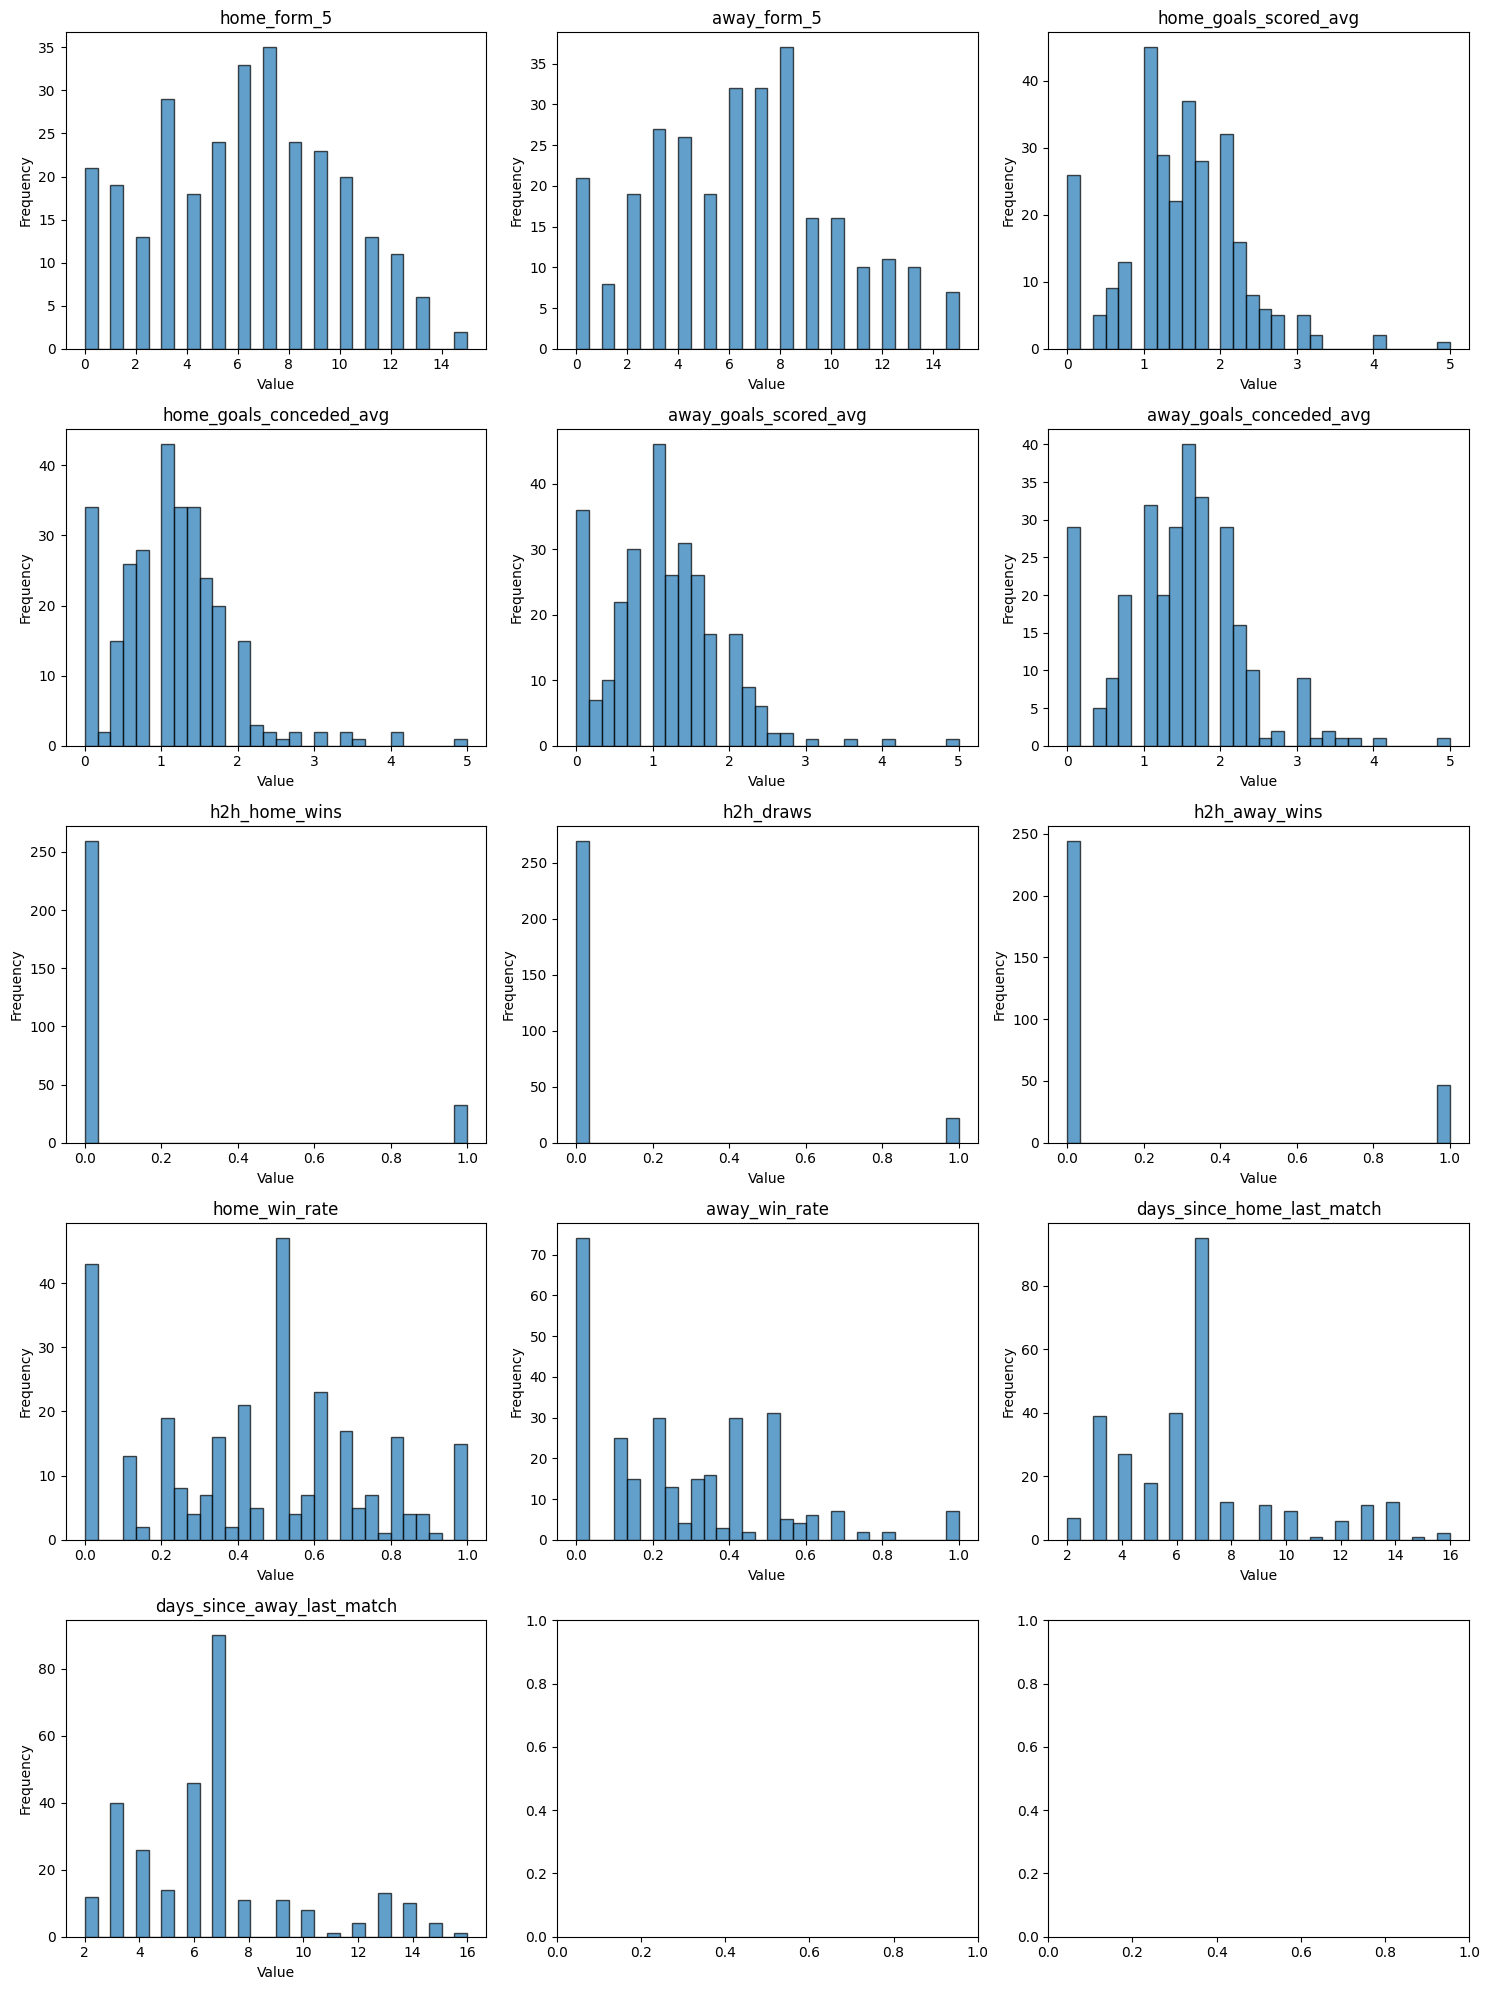

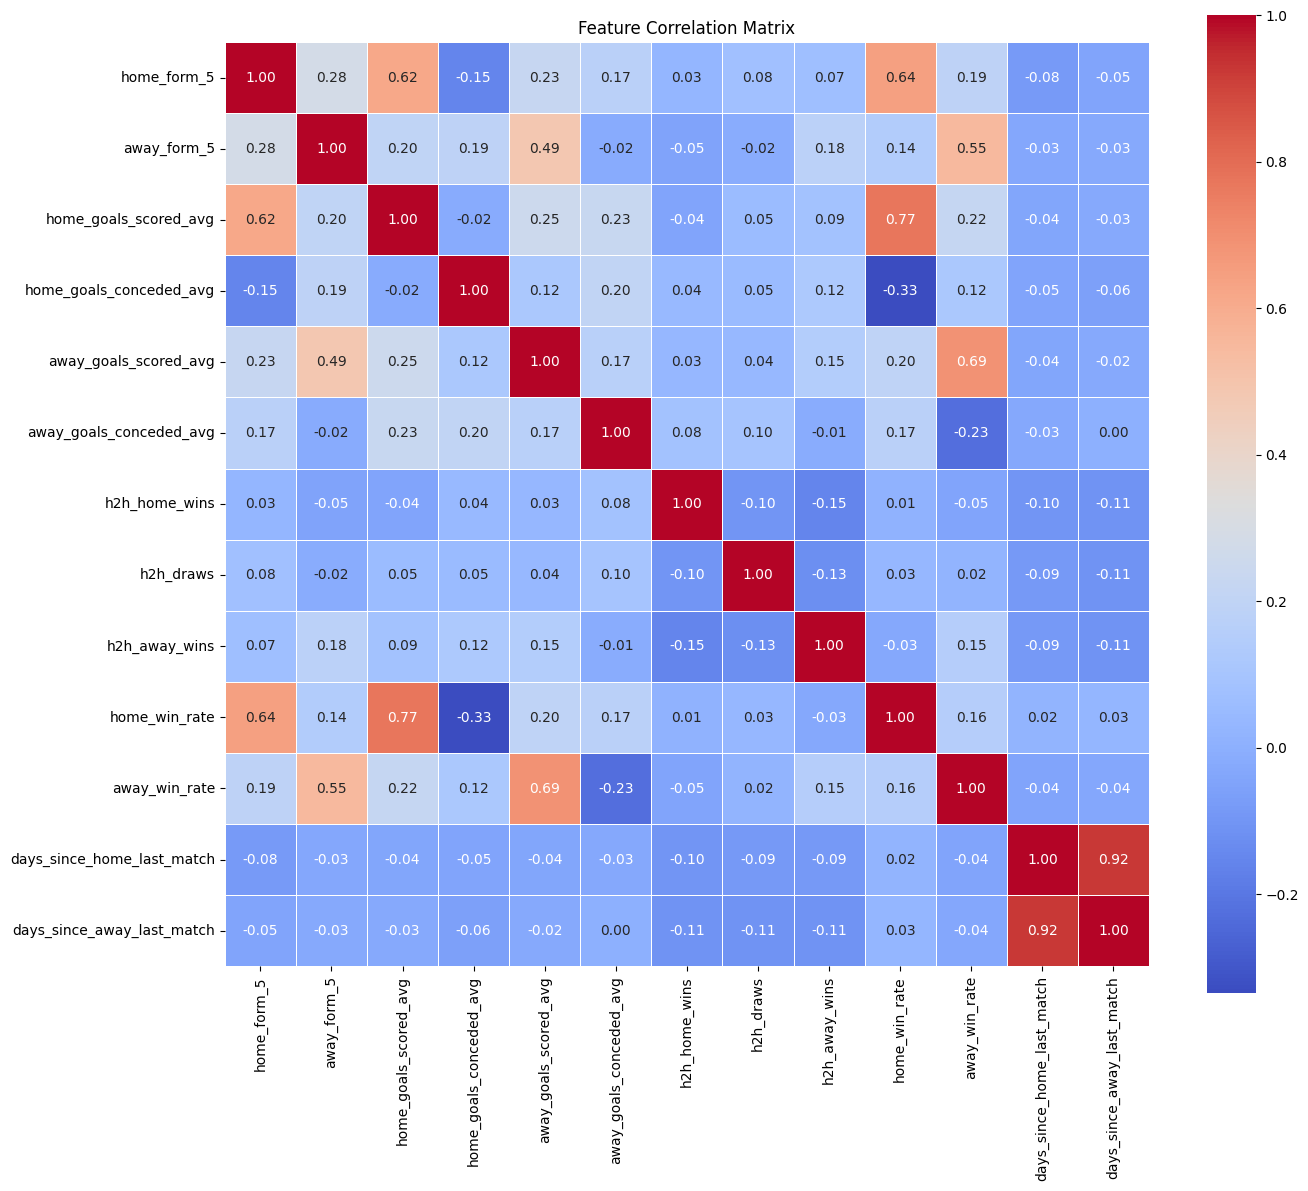

Highly correlated features (>0.7):
home_goals_scored_avg <-> home_win_rate: 0.774
days_since_home_last_match <-> days_since_away_last_match: 0.924

Feature correlation with target (absolute values):
home_goals_conceded_avg       0.165353
home_form_5                   0.158178
home_win_rate                 0.142095
home_goals_scored_avg         0.125273
away_form_5                   0.122061
away_win_rate                 0.100920
h2h_away_wins                 0.098609
away_goals_scored_avg         0.090449
h2h_home_wins                 0.043902
days_since_home_last_match    0.037136
away_goals_conceded_avg       0.033159
days_since_away_last_match    0.032773
h2h_draws                     0.005237
dtype: float64


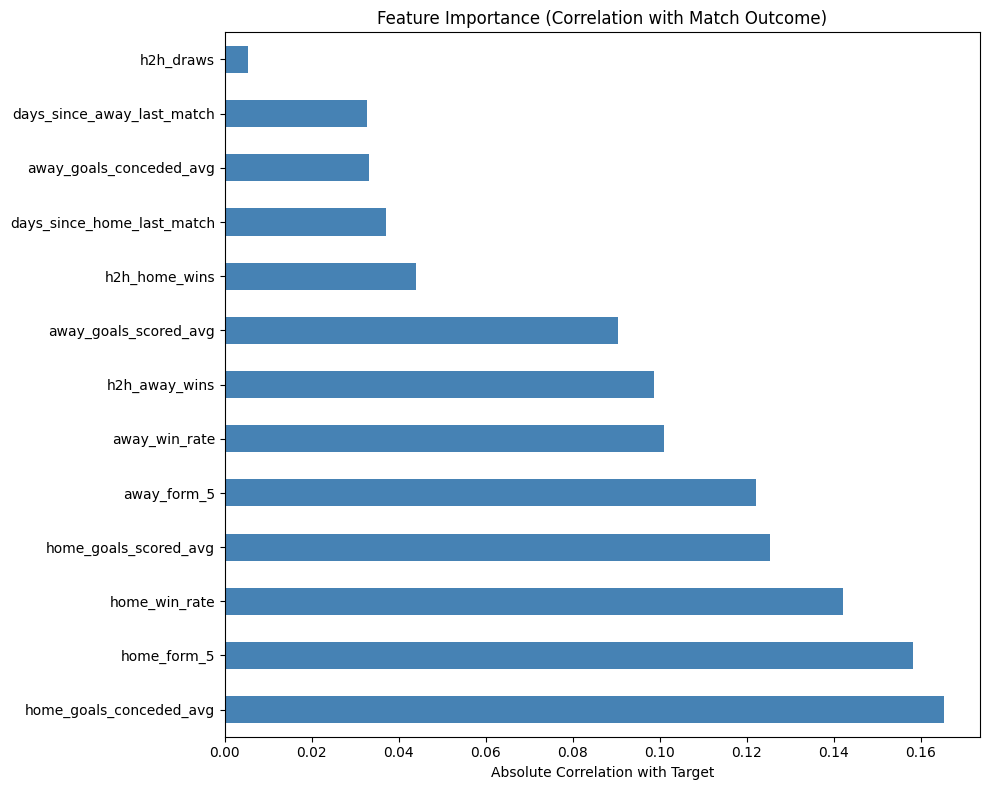


FEATURE ANALYSIS INSIGHTS:

1. Dataset Size: 291 matches with features

2. Missing Data:
   - days_since_home/away_last_match: 0 missing (matchday 1)
   - Fix: Fill with median (7 days) before training

3. Most Important Features (by correlation with target):
home_goals_conceded_avg    0.165353
home_form_5                0.158178
home_win_rate              0.142095
home_goals_scored_avg      0.125273
away_form_5                0.122061
away_win_rate              0.100920

4. Highly Correlated Pairs (>0.7):
   - home_goals_scored_avg <-> home_win_rate: 0.774
   - days_since_home_last_match <-> days_since_away_last_match: 0.924
   - Action: Drop days_since_away_last_match (redundant)

5. Feature Ranges:
   - Form: 0-15 (5 games x 3 points max)
   - Goals average: typically 0-3
   - Win rates: 0-1 (0%% to 100%%)
   - Rest days: 2-16

6. Recommendations:
   - Home features are stronger predictors than away features
   - Defensive stats (goals conceded) most predictive
   - H2H features ar

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load features
df = pd.read_csv('../data/processed/match_features.csv')

print("Feature Dataset Shape:", df.shape)
print("\nColumns:" ,list(df.columns))
df.head()

print("Missing values:")
print(df.isnull().sum())

# Calculate percentage of missing
print("\nMissing percentage:")
print((df.isnull().sum() / len(df) * 100).round(2))

# Fill missing rest days with median (matchday 1 teams have no previous match)
df['days_since_home_last_match'] = df['days_since_home_last_match'].fillna(df['days_since_home_last_match'].median())
df['days_since_away_last_match'] = df['days_since_away_last_match'].fillna(df['days_since_away_last_match'].median())

# Select feature columns (excluding match_id, target, date, season, team names)
feature_cols = [
    'home_form_5', 'away_form_5',
    'home_goals_scored_avg', 'home_goals_conceded_avg',
    'away_goals_scored_avg', 'away_goals_conceded_avg',
    'h2h_home_wins', 'h2h_draws', 'h2h_away_wins',
    'home_win_rate', 'away_win_rate',
    'days_since_home_last_match', 'days_since_away_last_match'
]

# Plot distrubutions
fig, axes = plt.subplots(5, 3, figsize=(15, 20))
axes = axes.ravel()

for idx, col in enumerate(feature_cols):
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col}')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../data/feature_distributions.png', dpi=300)
plt.show()

# Calculate correlation matrix
correlation_matrix = df[feature_cols].corr()

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../data/feature_correlation.png', dpi=300)
plt.show()

print("Highly correlated features (>0.7):")
# Find paris with high correlation
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            print(f"{correlation_matrix.columns[i]} <-> {correlation_matrix.columns[j]}: {correlation_matrix.iloc[i, j]:.3f}")

# Encode target
target_encoded = df['target'].map({
    'HOME_TEAM': 2,
    'DRAW': 1,
    'AWAY_TEAM': 0
})

# Calculate correlation with target
feature_target_corr = df[feature_cols].corrwith(target_encoded).abs().sort_values(ascending=False)

print("\nFeature correlation with target (absolute values):")
print(feature_target_corr)

# Plot
plt.figure(figsize=(10, 8))
feature_target_corr.plot(kind='barh', color='steelblue')
plt.xlabel('Absolute Correlation with Target')
plt.title('Feature Importance (Correlation with Match Outcome)')
plt.tight_layout()
plt.savefig('../data/feature_target_correlation.png', dpi=300)
plt.show()

insights = f"""
FEATURE ANALYSIS INSIGHTS:

1. Dataset Size: {len(df)} matches with features

2. Missing Data:
   - days_since_home/away_last_match: {df['days_since_home_last_match'].isnull().sum()} missing (matchday 1)
   - Fix: Fill with median ({df['days_since_home_last_match'].median():.0f} days) before training

3. Most Important Features (by correlation with target):
{feature_target_corr.head(6).to_string()}

4. Highly Correlated Pairs (>0.7):
   - home_goals_scored_avg <-> home_win_rate: 0.774
   - days_since_home_last_match <-> days_since_away_last_match: 0.924
   - Action: Drop days_since_away_last_match (redundant)

5. Feature Ranges:
   - Form: 0-15 (5 games x 3 points max)
   - Goals average: typically 0-3
   - Win rates: 0-1 (0%% to 100%%)
   - Rest days: 2-16

6. Recommendations:
   - Home features are stronger predictors than away features
   - Defensive stats (goals conceded) most predictive
   - H2H features are weak with 1 season — will improve with more data
   - Ready for model training
"""

print(insights)

with open('../data/feature_insights.txt', 'w') as f:
    f.write(insights)